# Лабораторная работа: полносвязная искусственная нейронная сеть

## Выбранный датасет

**California Housing** — набор данных о стоимости жилья в Калифорнии.

- 20 640 объектов и 8 числовых признаков;
- целевая переменная: медианная стоимость жилья;
- задача: регрессия;
- метрика качества: MSE (Mean Squared Error), чем меньше значение, тем лучше.

Ссылки:

- [Описание датасета в scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)
- [Версия датасета на Kaggle](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

В работе данные стандартизируются, затем выборка делится на обучающую и тестовую части. Архитектура сети подбирается по нескольким вариантам скрытых слоев, а лучшая модель выбирается по минимальному MSE на валидационной выборке.

In [2]:
%pip install numpy pandas matplotlib scikit-learn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.6 MB 7.8 MB/s eta 0:00:01
   --------- ------------------------------ 2.4/9.6 MB 7.8 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.6 MB 6.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 7.2 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 7.8 MB/s  0:00:01
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.3 MB 8.0 MB/s eta 0:00:01
   ----------- ---------------------------- 2.6/9.3 MB 6.1 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.3 MB 7.5 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Размер признаков: (20640, 8)
Пропуски: 0
Среднее значение целевой переменной: 2.069

Сравнение архитектур:


,Архитектура,MSE на validation,Число итераций
2,"2 скрытых слоя (128, 64)",0.262603,160
3,"3 скрытых слоя (128, 64, 32)",0.269196,73
1,"2 скрытых слоя (64, 32)",0.272863,131
0,1 скрытый слой (64),0.287481,225



Лучшая архитектура: 2 скрытых слоя (128, 64)
MSE на тестовой выборке:  0.2721
RMSE на тестовой выборке: 0.5216
MAE на тестовой выборке:  0.3534
R² на тестовой выборке:   0.7924


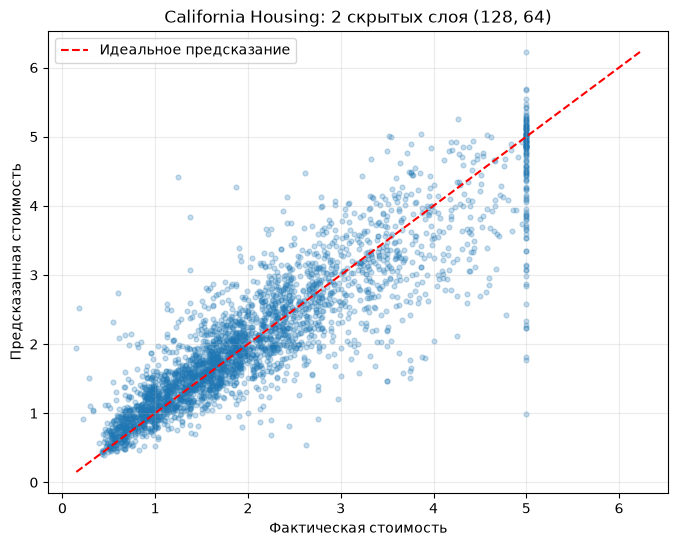

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

# 1. Загрузка датасета
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(f"Размер признаков: {X.shape}")
print(f"Пропуски: {X.isna().sum().sum()}")
print(f"Среднее значение целевой переменной: {y.mean():.3f}")

# 2. Деление данных на train, validation и test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=RANDOM_STATE
)

# 3. Масштабирование признаков и целевой переменной
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_valid_scaled = x_scaler.transform(X_valid)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(np.asarray(y_train).reshape(-1, 1)).ravel()

# 4. Обучение и сравнение нескольких полносвязных архитектур
architectures = {
    "1 скрытый слой (64)": (64,),
    "2 скрытых слоя (64, 32)": (64, 32),
    "2 скрытых слоя (128, 64)": (128, 64),
    "3 скрытых слоя (128, 64, 32)": (128, 64, 32),
}

results = []
models = {}

for name, hidden_layers in architectures.items():
    model = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        batch_size=128,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train_scaled)

    valid_prediction_scaled = model.predict(X_valid_scaled)
    valid_prediction = y_scaler.inverse_transform(
        valid_prediction_scaled.reshape(-1, 1)
    ).ravel()
    valid_mse = mean_squared_error(y_valid, valid_prediction)

    models[name] = model
    results.append({
        "Архитектура": name,
        "MSE на validation": valid_mse,
        "Число итераций": model.n_iter_,
    })

results_df = pd.DataFrame(results).sort_values("MSE на validation")
print("\nСравнение архитектур:")
display(results_df)

# 5. Выбор лучшей архитектуры и финальная проверка на test
best_name = results_df.iloc[0]["Архитектура"]
best_model = models[best_name]
test_prediction_scaled = best_model.predict(X_test_scaled)
test_prediction = y_scaler.inverse_transform(
    test_prediction_scaled.reshape(-1, 1)
).ravel()

test_mse = mean_squared_error(y_test, test_prediction)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, test_prediction)
test_r2 = r2_score(y_test, test_prediction)

print(f"\nЛучшая архитектура: {best_name}")
print(f"MSE на тестовой выборке:  {test_mse:.4f}")
print(f"RMSE на тестовой выборке: {test_rmse:.4f}")
print(f"MAE на тестовой выборке:  {test_mae:.4f}")
print(f"R² на тестовой выборке:   {test_r2:.4f}")

# 6. График фактических и предсказанных значений
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_prediction, alpha=0.25, s=12)
line_min = min(y_test.min(), test_prediction.min())
line_max = max(y_test.max(), test_prediction.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", label="Идеальное предсказание")
plt.xlabel("Фактическая стоимость")
plt.ylabel("Предсказанная стоимость")
plt.title(f"California Housing: {best_name}")
plt.legend()
plt.grid(alpha=0.25)
plt.show()